Exploratory Data Analysis (EDA) - Phân Tích Khám Phá Dữ Liệu Xe Cũ
Notebook này chứa các phân tích thống kê mô tả và trực quan hóa dữ liệu để tìm hiểu xu hướng của thị trường xe cũ.
Mỗi biểu đồ đều đi kèm giải thích chi tiết ý nghĩa kinh doanh.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [8]:
# Cấu hình style cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
# Đọc dữ liệu
df = pd.read_csv('../data/processed/cars_cleaned.csv')
print("Kích thước dữ liệu:", df.shape)
df.head(3)

Kích thước dữ liệu: (13520, 36)


,list_id,ad_id,subject,price,price_string,category,category_name,condition_ad,condition_ad_name,carbrand,...,list_time,orig_list_time,number_of_images,type,status,fetched_at,price_million,flag_chinh_chu,flag_bao_duong_hang,car_age
0,94613937,131588155,ISUZU DMAX NHẬP THÁI SỐ TỰ ĐỘNG SIÊU KENG RẤT ĐẸP,475000000,475.000.000 đ,2010,Ô tô,1,Đã sử dụng,13,...,1786860877000,NaN,12,s,active,2026-09-14T06:19:28.426335+00:00,475.0,0,0,12
1,101546338,140022407,Ranger XLS AT,615000000,615.000.000 đ,2010,Ô tô,1,Đã sử dụng,3,...,1787635662939,1.786291e+12,15,s,active,2026-09-14T06:22:18.715141+00:00,615.0,0,0,1
2,101725648,140238757,terano ll máy dầu 7 chỗ diezen 2 cầu tubo xe đẹp,140000000,140.000.000 đ,2010,Ô tô,1,Đã sử dụng,19,...,1785372154000,NaN,8,s,active,2026-09-14T06:14:39.741275+00:00,140.0,0,0,24


### 1. Thống Kê Mô Tả (Descriptive Statistics)
Cung cấp cái nhìn tổng quan về các giá trị cốt lõi: giá trung bình, khoảng giá trị ODO, và độ tuổi của xe.

In [9]:
# Thống kê các cột số chính
df[['price_million', 'mileage_v2', 'mfdate', 'car_age']].describe().round(2)

,price_million,mileage_v2,mfdate,car_age
count,13520.00,13520.00,13520.00,13520.00
mean,456.46,68326.41,2018.26,7.74
std,245.75,49012.72,5.99,5.99
min,20.00,0.00,1980.00,0.00
25%,275.00,28000.00,2016.00,3.00
50%,425.00,64999.50,2020.00,6.00
75%,605.00,100000.00,2023.00,10.00
max,1180.00,204601.00,2026.00,46.00


### 2. Phân Phối Giá Xe (Price Distribution)
**Ý nghĩa biểu đồ:** Biểu đồ Histogram kết hợp đường KDE (Kernel Density Estimation) giúp chúng ta xem xe cũ tập trung chủ yếu ở phân khúc giá nào. Nhìn vào biểu đồ có thể thấy sự phân bổ (lệch phải hay chuẩn) của thị trường.

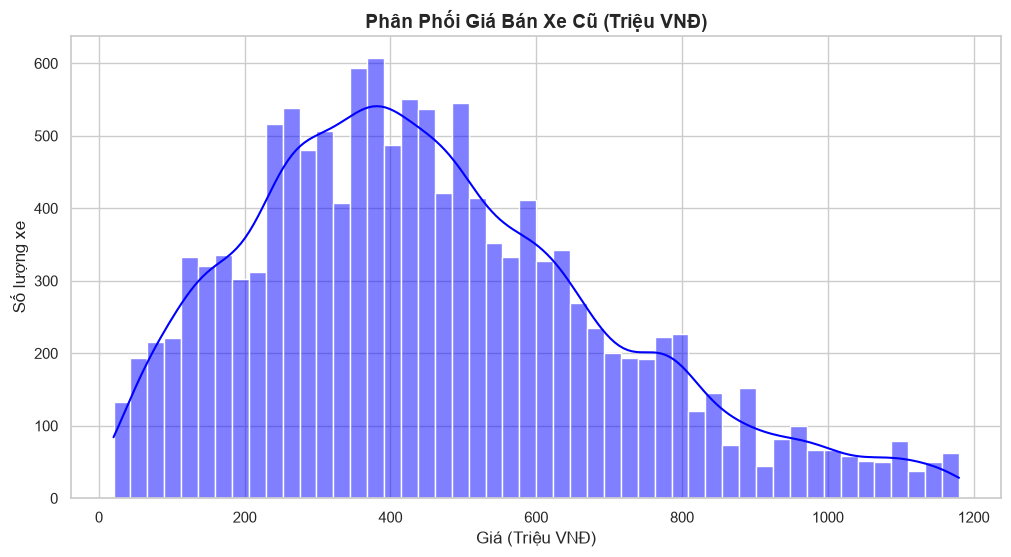

In [10]:
plt.figure(figsize=(12, 6))
sns.histplot(df['price_million'], bins=50, kde=True, color='blue')
plt.title('Phân Phối Giá Bán Xe Cũ (Triệu VNĐ)', fontsize=14, fontweight='bold')
plt.xlabel('Giá (Triệu VNĐ)', fontsize=12)
plt.ylabel('Số lượng xe', fontsize=12)
plt.show()

### 3. Phân Phối Số Km Đã Đi (ODO Distribution)
**Ý nghĩa biểu đồ:** Biểu đồ này hiển thị tần suất của mức ODO. Giúp xác định mức sử dụng trung bình của các xe đang được rao bán (ví dụ: xe lướt hay xe chạy dịch vụ nhiều).

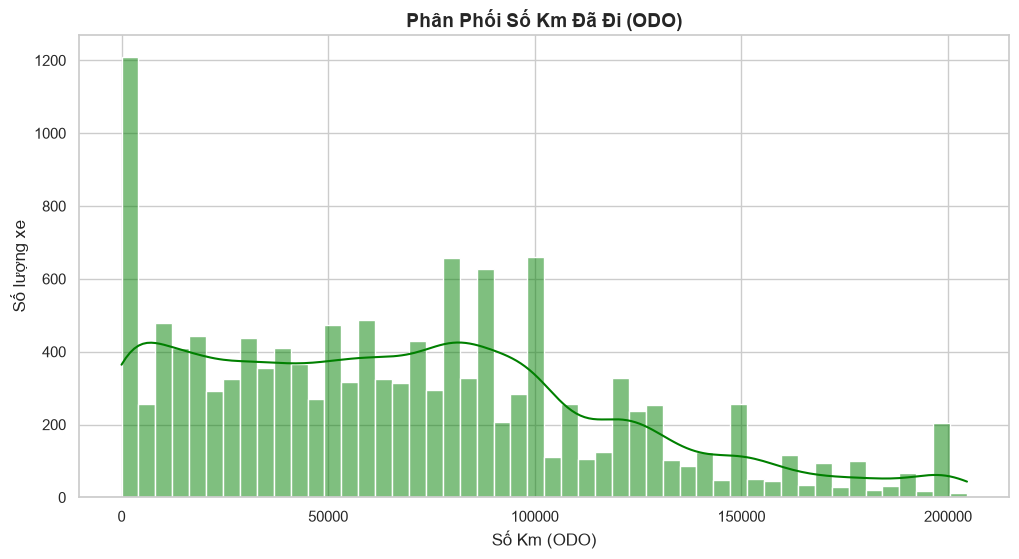

In [11]:
plt.figure(figsize=(12, 6))
sns.histplot(df['mileage_v2'], bins=50, kde=True, color='green')
plt.title('Phân Phối Số Km Đã Đi (ODO)', fontsize=14, fontweight='bold')
plt.xlabel('Số Km (ODO)', fontsize=12)
plt.ylabel('Số lượng xe', fontsize=12)
plt.show()

### 4. Phân Phối Năm Sản Xuất
**Ý nghĩa biểu đồ:** Cho thấy nguồn cung xe cũ trên thị trường chủ yếu đến từ những đời xe nào. Thường các xe sau 3-5 năm sử dụng sẽ được bán lại nhiều nhất.

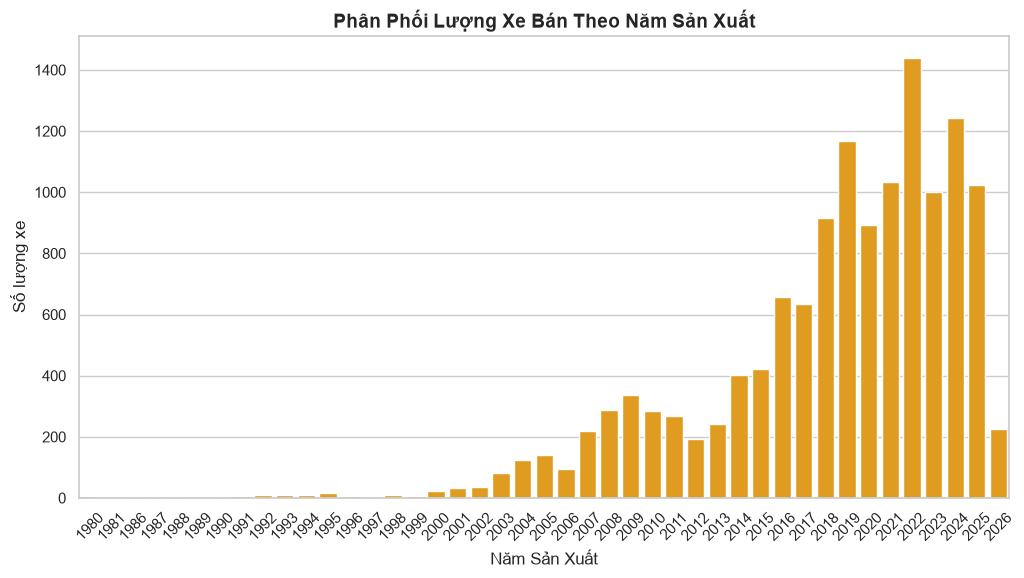

In [12]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='mfdate', color='orange')
plt.title('Phân Phối Lượng Xe Bán Theo Năm Sản Xuất', fontsize=14, fontweight='bold')
plt.xlabel('Năm Sản Xuất', fontsize=12)
plt.ylabel('Số lượng xe', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### 5. Giá Xe Theo Hãng Sản Xuất
**Ý nghĩa biểu đồ:** Boxplot so sánh mức giá và độ phân tán giá giữa top 10 hãng xe phổ biến nhất. Điểm chấm tròn là các giá trị ngoại lai (outliers), đường giữa hộp là giá trung vị (median). Giúp nhận diện phân khúc hạng sang (Mercedes, BMW) so với phổ thông (Toyota, Hyundai).

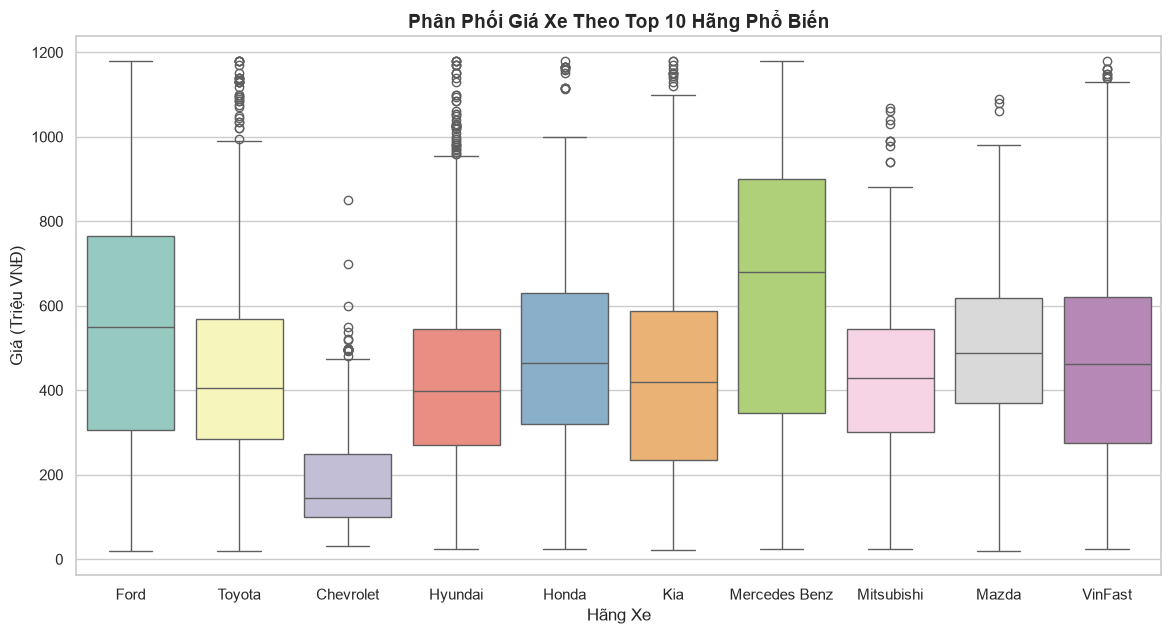

In [13]:
top_brands = df['carbrand_name'].value_counts().head(10).index
df_top_brands = df[df['carbrand_name'].isin(top_brands)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_top_brands, x='carbrand_name', y='price_million', palette='Set3')
plt.title('Phân Phối Giá Xe Theo Top 10 Hãng Phổ Biến', fontsize=14, fontweight='bold')
plt.xlabel('Hãng Xe', fontsize=12)
plt.ylabel('Giá (Triệu VNĐ)', fontsize=12)
plt.show()

### 6. Khấu Hao Giá Theo Năm Sản Xuất
**Ý nghĩa biểu đồ:** Biểu diễn sự rớt giá của xe qua từng năm sản xuất. Dữ liệu gộp (groupby) theo trung vị giá của mỗi năm. Đường đi xuống thể hiện xe càng cũ (năm sản xuất nhỏ) thì giá càng giảm.

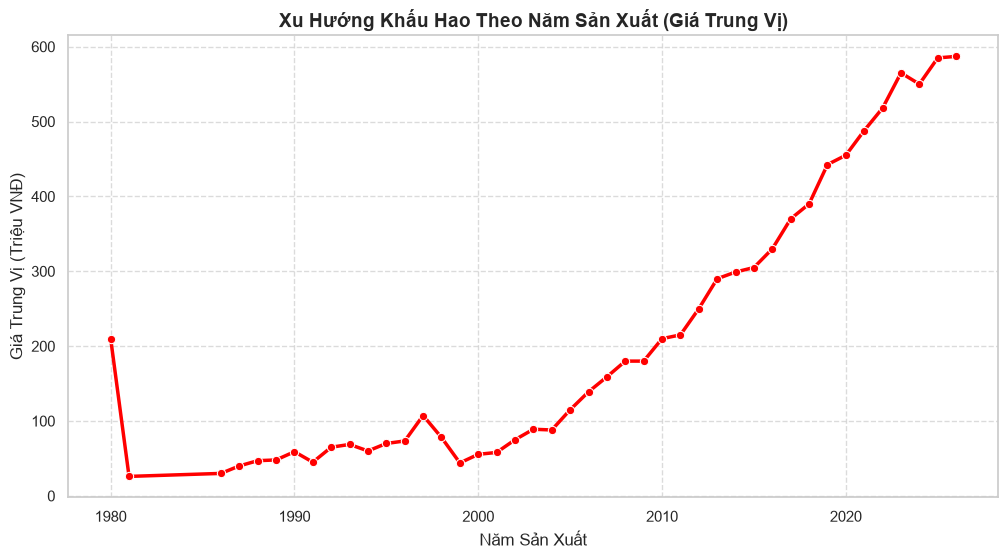

In [14]:
price_by_year = df.groupby('mfdate')['price_million'].median().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=price_by_year, x='mfdate', y='price_million', marker='o', linewidth=2.5, color='red')
plt.title('Xu Hướng Khấu Hao Theo Năm Sản Xuất (Giá Trung Vị)', fontsize=14, fontweight='bold')
plt.xlabel('Năm Sản Xuất', fontsize=12)
plt.ylabel('Giá Trung Vị (Triệu VNĐ)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 7. Tác Động Của ODO Đến Giá Xe
**Ý nghĩa biểu đồ:** Scatter plot (Biểu đồ phân tán) có chứa đường hồi quy (trendline) cho thấy mối tương quan nghịch giữa số km đã chạy và giá bán. Xe đi càng nhiều (ODO cao) thì giá trị (thường) càng thấp.

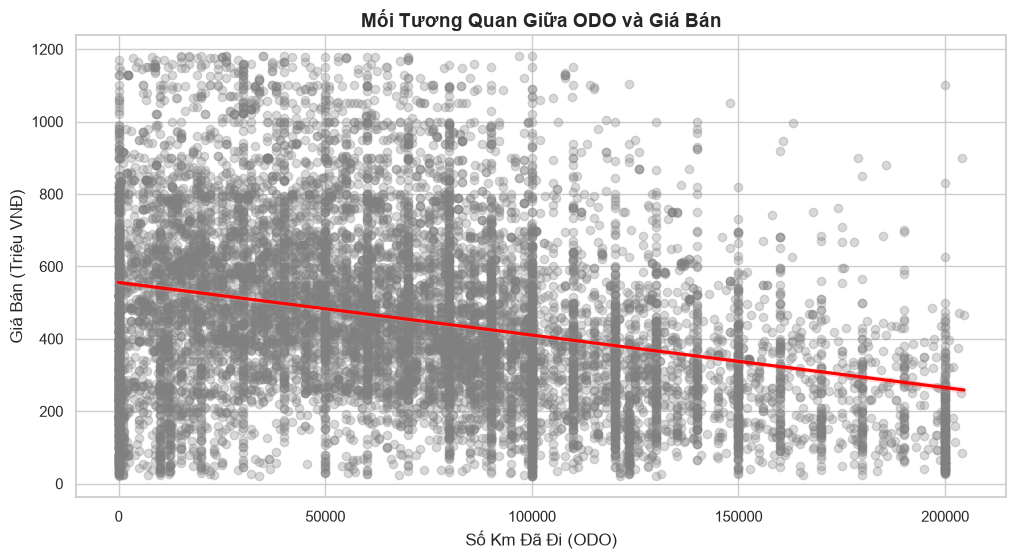

In [15]:
plt.figure(figsize=(12, 6))
# Dùng regplot để vẽ điểm và đường xu hướng
sns.regplot(data=df, x='mileage_v2', y='price_million', scatter_kws={'alpha':0.3, 'color':'gray'}, line_kws={'color':'red'})
plt.title('Mối Tương Quan Giữa ODO và Giá Bán', fontsize=14, fontweight='bold')
plt.xlabel('Số Km Đã Đi (ODO)', fontsize=12)
plt.ylabel('Giá Bán (Triệu VNĐ)', fontsize=12)
plt.show()